In [2]:
import pandas as pd
import numpy as np 
import torch 
from pathlib import Path
import os 

In [3]:
dataset = Path('/kaggle/input/biggest-genderface-recognition-dataset/faces')
gender_df_model = dataset

In [4]:
gender_df_model 

PosixPath('/kaggle/input/biggest-genderface-recognition-dataset/faces')

In [5]:
gender_image = []

def convert_df(folder_Path):
    for folder_name in os.listdir(folder_Path):
        folder_path = os.path.join(folder_Path, folder_name)
        
        if os.path.isdir(folder_path):
            for image_name in os.listdir(folder_path):
                if image_name.endswith(('.png', '.jpg', '.jpeg')):  # Filter image types
                    image_path = os.path.join(folder_path, image_name)
                    if folder_Path == gender_df_model:
                        gender_image.append({'image_path': image_path, 'label': folder_name})


In [6]:
gender_df = convert_df(gender_df_model)

gender_df = pd.DataFrame(gender_image)

In [7]:
gender_df

,image_path,label
0,/kaggle/input/biggest-genderface-recognition-d...,man
1,/kaggle/input/biggest-genderface-recognition-d...,man
2,/kaggle/input/biggest-genderface-recognition-d...,man
3,/kaggle/input/biggest-genderface-recognition-d...,man
4,/kaggle/input/biggest-genderface-recognition-d...,man
...,...,...
27162,/kaggle/input/biggest-genderface-recognition-d...,woman
27163,/kaggle/input/biggest-genderface-recognition-d...,woman
27164,/kaggle/input/biggest-genderface-recognition-d...,woman
27165,/kaggle/input/biggest-genderface-recognition-d...,woman


In [8]:
gender_df.shape

(27167, 2)

In [9]:
import pandas as pd
import numpy as np
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [10]:
def load_and_preprocess_data(gender_df, input_width, input_height):
    images = []
    labels = []
    
    for index, row in gender_df.iterrows():
        image_path = row['image_path']
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        image = cv2.resize(image, (input_width, input_height))  # Resize
        
        images.append(image)
        labels.append(row['label'])
    
    images = np.array(images) / 255.0  # Normalize images
    images = np.expand_dims(images, axis=-1)  # Add channels dimension
    
    return images, np.array(labels)

# Example DataFrame
# emotion_df = pd.read_csv('path_to_your_data.csv')  # Uncomment and set the correct path
#emotion_df = pd.DataFrame({'image_path': ['image1.jpg', 'image2.jpg'], 
                          # 'label': ['surprised', 'neutral']})  # Replace with your actual data


In [11]:
def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Adjust for classification
    return model


In [13]:
# Preparing the dataset
input_width, input_height = 100, 100  # Modify as needed
images, labels = load_and_preprocess_data(gender_df, input_width, input_height)

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(images, labels_categorical, test_size=0.2, random_state=42)

# Build the model
model = create_model((input_width, input_height, 1), len(le.classes_))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))


680/680 ━━━━━━━━━━━━━━━━━━━━ 152s 220ms/step - accuracy: 0.7453 - loss: 0.5018 - val_accuracy: 0.8482 - val_loss: 0.3530
Epoch 2/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 149s 219ms/step - accuracy: 0.8766 - loss: 0.2957 - val_accuracy: 0.8782 - val_loss: 0.2899
Epoch 3/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 150s 220ms/step - accuracy: 0.9153 - loss: 0.2138 - val_accuracy: 0.8888 - val_loss: 0.2733
Epoch 4/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 148s 218ms/step - accuracy: 0.9410 - loss: 0.1501 - val_accuracy: 0.8995 - val_loss: 0.2902
Epoch 5/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 150s 221ms/step - accuracy: 0.9693 - loss: 0.0865 - val_accuracy: 0.8933 - val_loss: 0.2829
Epoch 6/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 149s 219ms/step - accuracy: 0.9827 - loss: 0.0523 - val_accuracy: 0.9010 - val_loss: 0.3451
Epoch 7/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 147s 216ms/step - accuracy: 0.9915 - loss: 0.0284 - val_accuracy: 0.9043 - val_loss: 0.3858
Epoch 8/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 151s 223ms/step - accuracy: 0.9931 - loss: 0.02

In [14]:
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {accuracy:.2f}')


170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.8908 - loss: 0.4650
Validation Accuracy: 0.89


In [16]:
model.save('gender_model1.h5')

In [19]:
# Load your model
model = tf.keras.models.load_model('/kaggle/working/gender_model.h5')

# Print the model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,352,772 (16.60 MB)

 Trainable params: 4,352,770 (16.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [20]:
input_shape = model.input_shape
print(f"Expected input shape: {input_shape}")


Expected input shape: (None, 100, 100, 1)


In [32]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
import random

# Define the path to the UTKFace dataset
utkface_path = '/kaggle/input/datasets/alifshahariar/utkface-dataset-face-aligned-and-labeled/utkface-aligned-labeled/images'

# Load your trained model
model = tf.keras.models.load_model('/kaggle/working/gender_model.h5')

# Function to preprocess the image
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    img = cv2.resize(img, (100, 100))  # Resize to match model's input shape
    img = img.astype('float32') / 255.0  # Normalize to [0, 1]
    img = np.expand_dims(img, axis=-1)  # Add channel dimension
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Collect all image paths and corresponding genders
image_paths = []
actual_genders = []

for filename in os.listdir(utkface_path):
    if filename.endswith('.jpg'):
        image_paths.append(os.path.join(utkface_path, filename))
        # Extract gender from filename (assuming filename format is [age]_[gender]_[race]_[filename].jpg)
        gender = int(filename.split('_')[1])  # 0 for Female, 1 for Male
        actual_genders.append(gender)

# Sample 50 random images
random_indices = random.sample(range(len(image_paths)), 50)
sample_image_paths = [image_paths[i] for i in random_indices]
sample_actual_genders = [actual_genders[i] for i in random_indices]

# Initialize counters for accuracy
correct_predictions = 0

# List to maintain predicted genders
predicted_genders = []

images_to_display = []

# Iterate through sampled images to make predictions
for image_path, actual_gender in zip(sample_image_paths, sample_actual_genders):
    img = preprocess_image(image_path)

    # Make prediction
    prediction = model.predict(img)
    predicted_gender = np.argmax(prediction)  # 0 or 1
    predicted_genders.append(predicted_gender)

    # Count correct predictions
    if predicted_gender == actual_gender:
        correct_predictions += 1
    images_to_display.append((image_path, actual_gender, predicted_gender))
# Calculate overall accuracy
accuracy = correct_predictions / len(sample_image_paths)

# Output the results
for img_path, actual, predicted in zip(sample_image_paths, sample_actual_genders, predicted_genders):
    actual_label = 'Male' if actual == 1 else 'Female'
    predicted_label = 'Male' if predicted == 1 else 'Female'
    print(f'Image: {os.path.basename(img_path)}, Actual: {actual_label}, Predicted: {predicted_label}')

print(f'\nOverall Accuracy: {accuracy * 100:.2f}%')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

In [28]:
import matplotlib.pyplot as plt

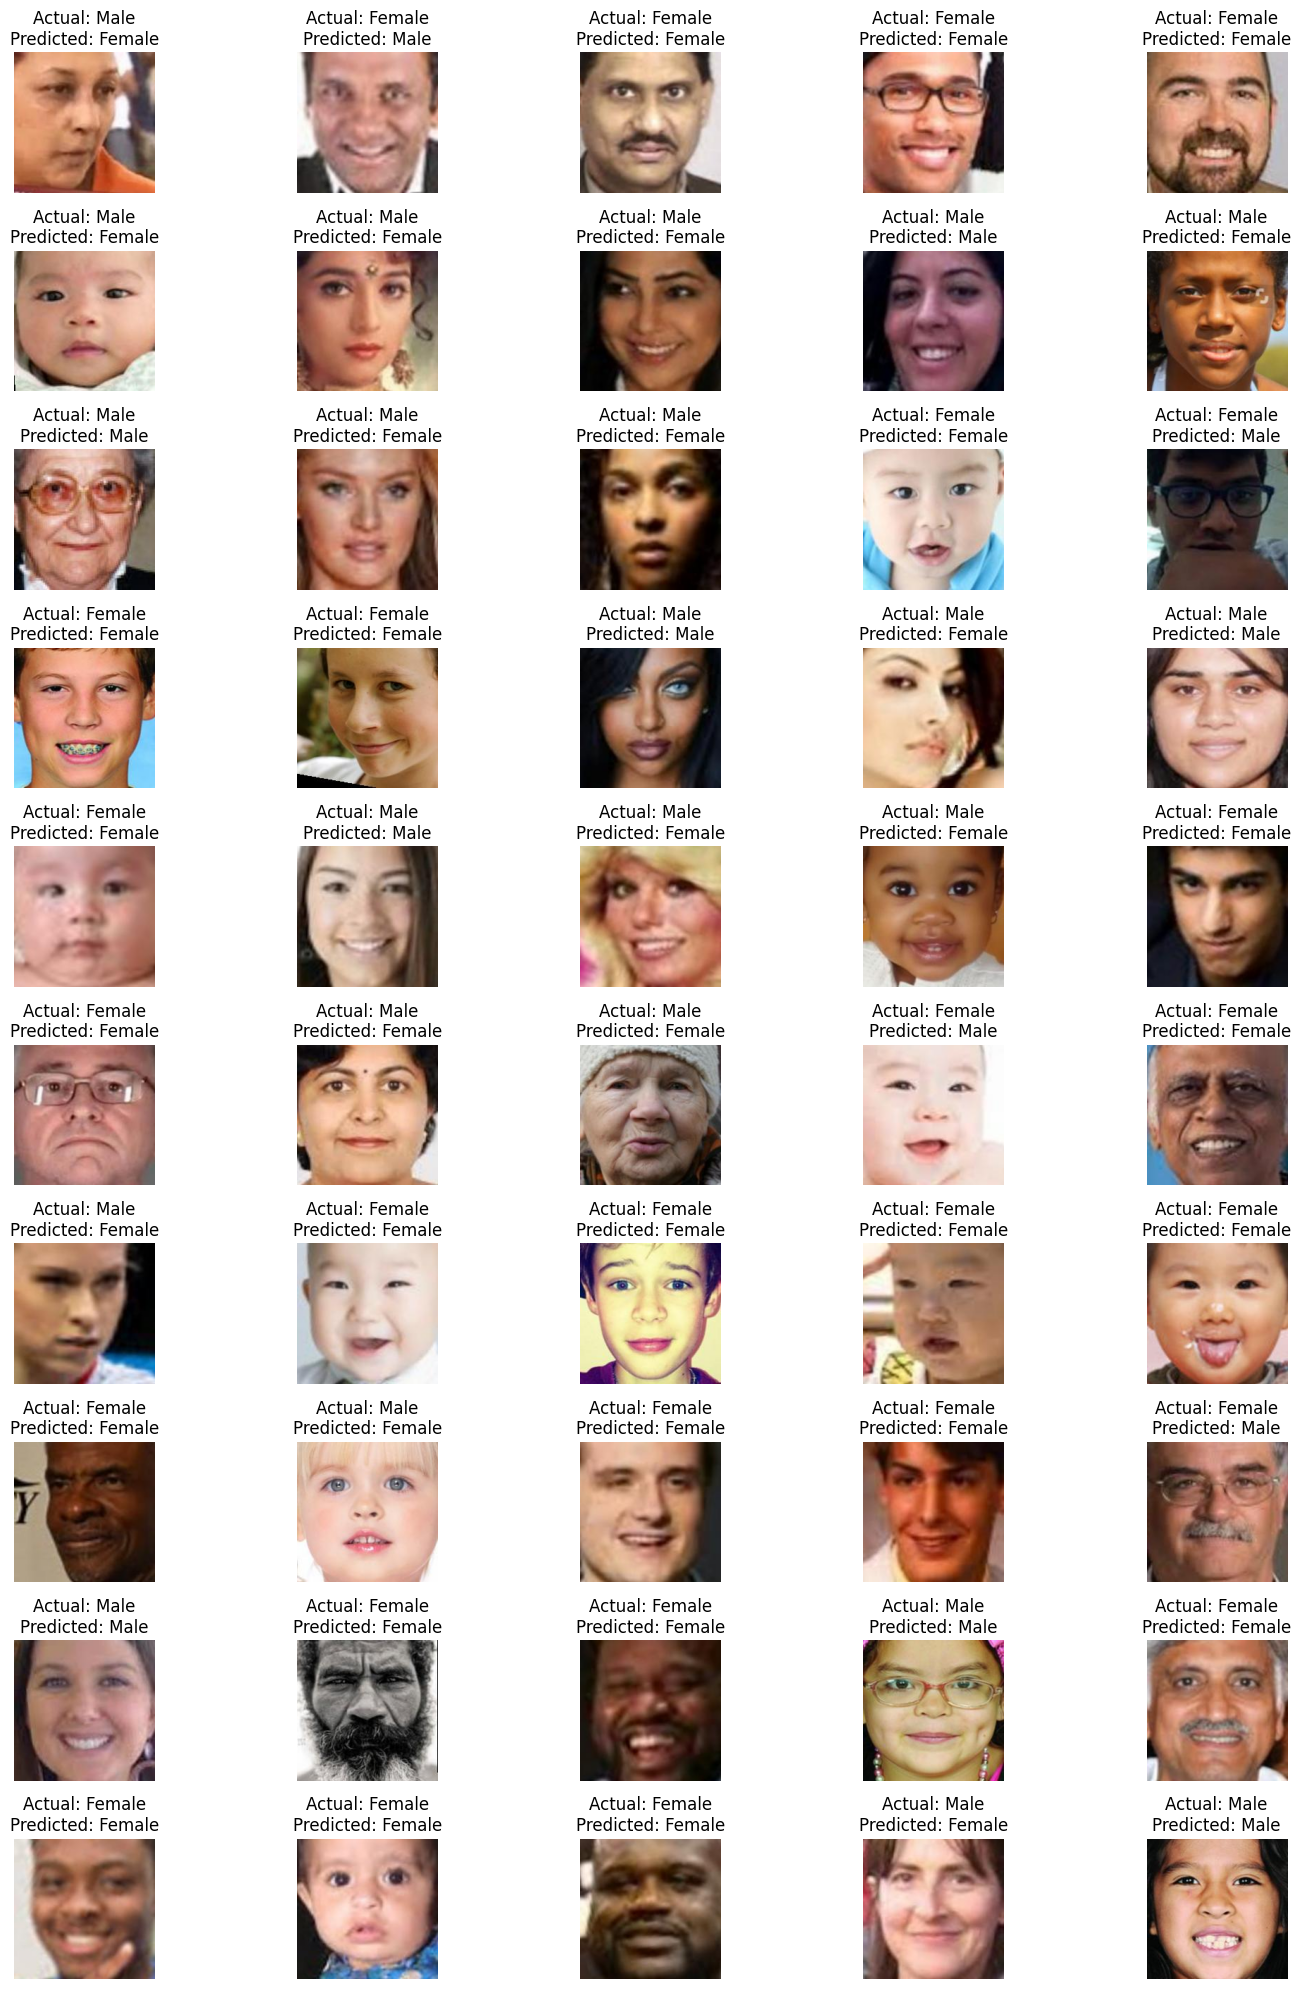

In [33]:
# Set up grid for displaying images
n_rows = 10
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for ax, (img_path, actual, predicted) in zip(axes, images_to_display):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert color format for matplotlib
    actual_label = 'Male' if actual == 1 else 'Female'
    predicted_label = 'Male' if predicted == 1 else 'Female'
    
    ax.imshow(img)
    ax.axis('off')  # Hide axes
    ax.set_title(f'Actual: {actual_label}\nPredicted: {predicted_label}')

plt.tight_layout()
plt.show()

In [37]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt

# Define the path to the new gender dataset
dataset_path = '/kaggle/input/datasets/humairmunir/gender-recognizer/dataset'  # Should contain 'men' and 'women' folders

# Load your trained model
model = tf.keras.models.load_model('/kaggle/working/gender_model.h5')

# Function to preprocess the image
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    img = cv2.resize(img, (100, 100))  # Resize to match model's input shape
    img = img.astype('float32') / 255.0  # Normalize to [0, 1]
    img = np.expand_dims(img, axis=-1)  # Add channel dimension
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Initialize lists for results
images_to_display = []
correct_predictions = 0
total_images = 0

# Iterate through 'men' and 'women' folders
for gender in ['men', 'women']:
    folder_path = os.path.join(dataset_path, gender)
    
    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.png', '.jpeg')):  # Include different image formats
            image_path = os.path.join(folder_path, filename)
            actual_gender = 1 if gender == 'men' else 0  # 1 for Male, 0 for Female
            img = preprocess_image(image_path)

            # Make prediction
            prediction = model.predict(img)
            predicted_gender = np.argmax(prediction)  # 0 or 1
            
            # Count correct predictions
            if predicted_gender == actual_gender:
                correct_predictions += 1
            
            total_images += 1
            images_to_display.append((image_path, actual_gender, predicted_gender))

# Calculate overall accuracy
accuracy = correct_predictions / total_images if total_images > 0 else 0

# Output the results
print(f'Overall Accuracy: {accuracy * 100:.2f}%\n')

# Set up grid for displaying images
n_rows = min(10, total_images)  # Limit rows to 10 max
n_cols = (total_images // n_rows) + (total_images % n_rows > 0)  # Calculate required columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 2))
axes = axes.flatten()

for ax, (img_path, actual, predicted) in zip(axes, images_to_display):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert color format for matplotlib
    actual_label = 'Male' if actual == 1 else 'Female'
    predicted_label = 'Male' if predicted == 1 else 'Female'
    
    ax.imshow(img)
    ax.axis('off')  # Hide axes
    ax.set_title(f'Actual: {actual_label}\nPredicted: {predicted_label}')

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/humairmunir/gender-recognizer/dataset/men'